## Analysis

My data analysis is seperated into 4 chapter - __Revenue, Products, Traffic and Sessions__. <br>



### Revenue Analysis

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd


df_sales = pd.read_csv("C:/Projekt_Ordner/Sales_Analysis/Data/Cleaned_Data/df_sales.csv")
df_sessions = pd.read_csv("C:/Projekt_Ordner/Sales_Analysis/Data/Cleaned_Data/df_sessions.csv")

print(df_sales.shape)
print(df_sessions.shape)

(40025, 14)
(472871, 11)


In [8]:
print(monthly_revenue["year_month"].dtype)
print(monthly_revenue["year_month"].head())


object
0    2012-03
1    2012-04
2    2012-05
3    2012-06
4    2012-07
Name: year_month, dtype: object


__Monthly Revenue__

In [12]:
df_sales["created_at"] = pd.to_datetime(df_sales["created_at"])

df_sales["year_month"] = df_sales["created_at"].dt.to_period("M")


monthly_revenue = (df_sales.groupby("year_month").agg
                   (total_revenue = ("price_usd", "sum"), 
                    total_cost = ("cogs_usd", "sum"), 
                    total_profit = ("profit_usd", "sum"), 
                    total_orders = ("order_id", "nunique"), 
                    items_sold = ("order_item_id", "count")
                    )
                    .reset_index()
                    )


monthly_revenue["year_month_dt"] = monthly_revenue["year_month"].dt.to_timestamp()

print(monthly_revenue.to_string(index=False))

year_month  total_revenue  total_cost  total_profit  total_orders  items_sold year_month_dt
   2012-03        2999.40     1169.40        1830.0            60          60    2012-03-01
   2012-04        4949.01     1929.51        3019.5            99          99    2012-04-01
   2012-05        5398.92     2104.92        3294.0           108         108    2012-05-01
   2012-06        6998.60     2728.60        4270.0           140         140    2012-06-01
   2012-07        8448.31     3293.81        5154.5           169         169    2012-07-01
   2012-08       11397.72     4443.72        6954.0           228         228    2012-08-01
   2012-09       14347.13     5593.63        8753.5           287         287    2012-09-01
   2012-10       18546.29     7230.79       11315.5           371         371    2012-10-01
   2012-11       30893.82    12044.82       18849.0           618         618    2012-11-01
   2012-12       25294.94     9861.94       15433.0           506         506   

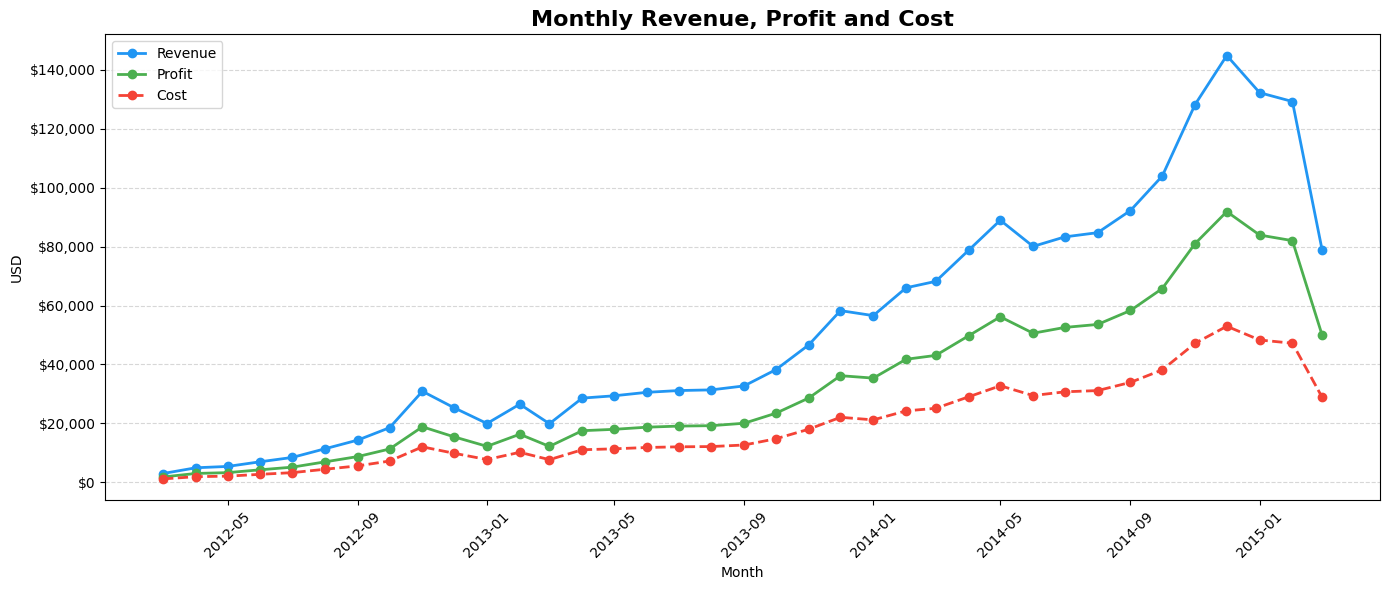

In [ ]:
# Plot - Monthly Revenue, Cost and Profit

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_revenue["year_month_dt"], monthly_revenue["total_revenue"],
        marker= "o", label = "Revenue", color = "#2196F3", linewidth=2)
ax.plot(monthly_revenue["year_month_dt"], monthly_revenue["total_profit"],
        marker= "o", label = "Profit",  color = "#4CAF50", linewidth=2)
ax.plot(monthly_revenue["year_month_dt"], monthly_revenue["total_cost"],
        marker= "o", label = "Cost",    color = "#F44336", linewidth=2, linestyle="--")

ax.set_title("Monthly Revenue, Profit and Cost", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Revenue is growing untill 2015 and declined then sharply. The Profit margin is stable. 

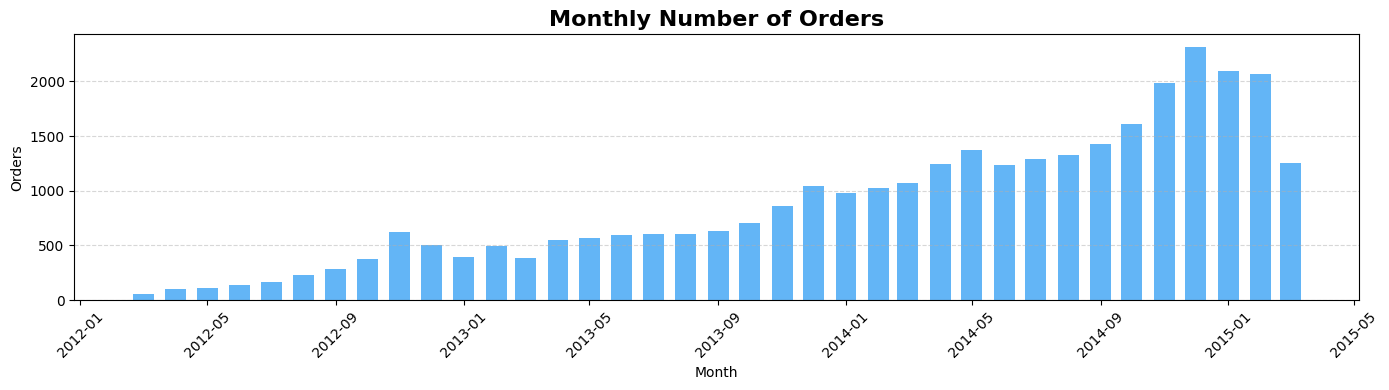

In [15]:
# Plot - Monthly Orders Volume

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(monthly_revenue["year_month_dt"], monthly_revenue["total_orders"], color="#2196F3", alpha=0.7, width=20)

ax.set_title("Monthly Number of Orders", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Monthly order figures have been rising steadily and at an ever-increasing rate since May 2014. Since 2015, monthly order figures have been falling.

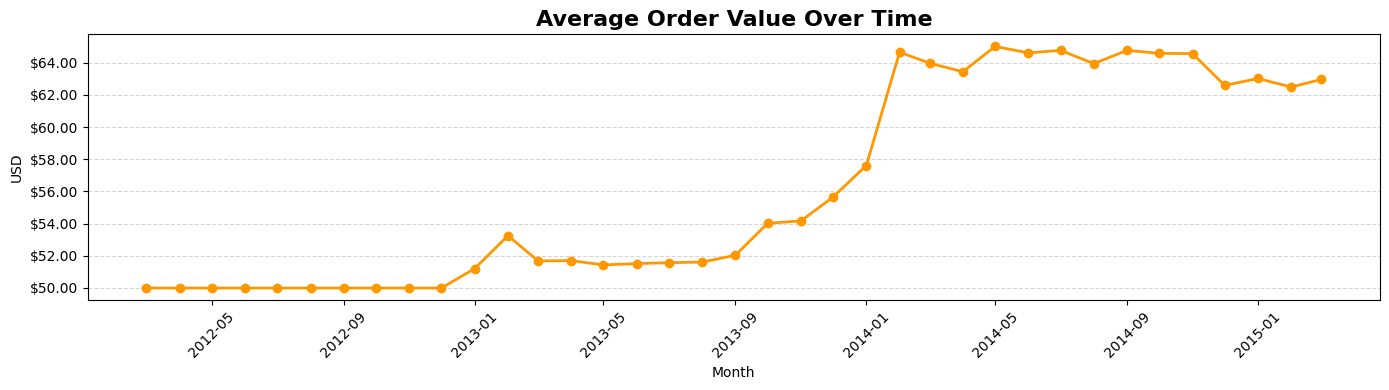

In [16]:
# Plot - Average Order Value over time

monthly_revenue["avg_order_value"] = (monthly_revenue["total_revenue"] / monthly_revenue["total_orders"])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_revenue["year_month_dt"], monthly_revenue["avg_order_value"], marker="o", color="#FF9800", linewidth=2)

ax.set_title("Average Order Value Over Time", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.2f}"))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

To begin with, order values rise steadily and gradually. This changes between September 2023 and January 2024, when a sharp increase can be observed. Thereafter, the figures stabilise at a high level.
